In [10]:
# Store generated datasets relative to the notebook's working directory.
from pathlib import Path

DATA_DIR = Path(".")
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"Dataset working directory: {DATA_DIR}")


Dataset working directory: .


In [3]:
"""Food Delivery Causal Policy Simulation
========================================

End-to-end workflow:
1. Generate synthetic customers, catalog, sessions, and experimental outcomes.
2. Compare observational, randomized, and ground-truth treatment effects.
3. Train and validate a dose-response model on randomized data.
4. Backtest organic, flat-discount, and bundle-aware optimized policies.

Requirements: numpy, pandas, scikit-learn, lightgbm
"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


@dataclass
class Config:
    n_customers: int = 5_000
    n_restaurants: int = 200
    sessions_per_customer: Tuple[int, int] = (1, 15)
    items_per_restaurant: Tuple[int, int] = (8, 15)
    bundles_per_restaurant: Tuple[int, int] = (2, 5)
    treatment_share_rct: float = 0.50
    incentive_levels: Tuple[float, ...] = (0.05, 0.10, 0.15, 0.20)
    base_fulfillment_cost: float = 30.0
    fulfillment_cost_per_km: float = 6.0
    weather_cost_multiplier: float = 10.0
    restaurant_cost_share: float = 0.65
    seed: int = 42
    backtest_sessions: int = 5_000
    cuisines: Tuple[str, ...] = (
        "north_indian", "south_indian", "chinese", "italian",
        "mughlai", "continental", "desserts", "beverages",
    )
    dayparts: Tuple[str, ...] = ("breakfast", "lunch", "dinner", "late_night")
    weather_types: Tuple[str, ...] = ("clear", "rain", "extreme")


CUSTOMER_FEATURES = [
    "locality_affluence", "historical_avg_spend", "budget_std_dev",
    "paycheck_expansion_ratio", "basket_discount_sensitivity",
    "restaurant_offer_sensitivity", "new_food_propensity", "loyalty_score",
]
SESSION_FEATURES = ["day_of_month", "day_of_week", "is_paycheck_week"]
CONTEXT_FEATURES = [
    f"dp_{value}" for value in ("breakfast", "lunch", "dinner", "late_night")
] + [f"wx_{value}" for value in ("clear", "rain", "extreme")]
BASE_FEATURES = CUSTOMER_FEATURES + SESSION_FEATURES + CONTEXT_FEATURES
BUNDLE_FEATURES = BASE_FEATURES + [
    "bundle_price", "bundle_cuisine_match", "bundle_novelty_score",
    "bundle_price_fit", "bundle_price_ratio", "bundle_margin_pct",
]
DOSE_FEATURES = BUNDLE_FEATURES + [
    "basket_discount_depth", "restaurant_offer_depth",
]


def generate_customers(cfg: Config, rng: np.random.Generator) -> pd.DataFrame:
    count = cfg.n_customers
    affluence = rng.beta(3, 3, size=count)
    spend = rng.lognormal(3.0, 0.4, size=count) * (0.8 + 0.6 * affluence) * 100
    cuisine_preferences = rng.dirichlet(np.full(len(cfg.cuisines), 0.8), size=count)
    customers = pd.DataFrame({
        "customer_id": np.arange(count),
        "locality_affluence": np.round(affluence, 3),
        "historical_avg_spend": np.round(spend, 2),
        "budget_std_dev": np.round(spend * rng.uniform(0.10, 0.35, count), 2),
        "paycheck_expansion_ratio": np.round(rng.uniform(1.15, 1.60, count), 2),
        "basket_discount_sensitivity": np.round(rng.beta(2, 4, count), 3),
        "restaurant_offer_sensitivity": np.round(rng.beta(3, 3, count), 3),
        "new_food_propensity": np.round(rng.beta(2, 5, count), 3),
        "loyalty_score": np.round(rng.beta(4, 2, count), 3),
    })
    preferences = pd.DataFrame(
        np.round(cuisine_preferences, 4),
        columns=[f"pref_{cuisine}" for cuisine in cfg.cuisines],
    )
    return pd.concat([customers, preferences], axis=1)


def generate_catalog(
    cfg: Config, rng: np.random.Generator
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    restaurant_rows, item_rows, bundle_rows = [], [], []
    item_id = bundle_id = 0
    for restaurant_id in range(cfg.n_restaurants):
        cuisine = str(rng.choice(cfg.cuisines))
        margin = float(rng.uniform(0.18, 0.40))
        restaurant_rows.append({
            "restaurant_id": restaurant_id,
            "cuisine": cuisine,
            "base_margin": round(margin, 3),
            "prep_time_mins": int(rng.integers(12, 40)),
            "inventory_capacity": int(rng.integers(40, 200)),
            "fulfillment_distance_km": round(float(rng.uniform(0.8, 8.5)), 2),
        })
        restaurant_items = []
        for _ in range(int(rng.integers(*cfg.items_per_restaurant))):
            price = float(rng.lognormal(2.6, 0.35) * 10)
            item = {
                "item_id": item_id,
                "restaurant_id": restaurant_id,
                "cuisine": cuisine,
                "price": round(price, 2),
                "cost": round(price * (1 - margin), 2),
                "is_new": bool(rng.random() < 0.12),
                "category": str(rng.choice(["main", "side", "beverage", "dessert"])),
            }
            item_rows.append(item)
            restaurant_items.append(item)
            item_id += 1
        for _ in range(int(rng.integers(*cfg.bundles_per_restaurant))):
            selected = rng.choice(restaurant_items, size=min(3, len(restaurant_items)), replace=False)
            bundle_rows.append({
                "bundle_id": bundle_id,
                "restaurant_id": restaurant_id,
                "bundle_name": f"Bundle_{bundle_id}_Rest_{restaurant_id}",
                "cuisine": cuisine,
                "item_ids": [item["item_id"] for item in selected],
                "base_price": round(sum(item["price"] for item in selected) * 0.95, 2),
                "base_cost": round(sum(item["cost"] for item in selected), 2),
                "has_new_item": any(item["is_new"] for item in selected),
            })
            bundle_id += 1
    return pd.DataFrame(restaurant_rows), pd.DataFrame(item_rows), pd.DataFrame(bundle_rows)


def generate_sessions(
    customers: pd.DataFrame, cfg: Config, rng: np.random.Generator
) -> pd.DataFrame:
    rows = []
    session_id = 0
    start_date = pd.Timestamp("2026-01-01")
    for customer_id in customers["customer_id"]:
        for _ in range(int(rng.integers(*cfg.sessions_per_customer))):
            timestamp = start_date + pd.Timedelta(
                days=int(rng.integers(0, 180)), hours=int(rng.integers(0, 24))
            )
            rows.append({
                "session_id": session_id,
                "customer_id": int(customer_id),
                "timestamp": timestamp,
                "day_of_month": timestamp.day,
                "day_of_week": timestamp.dayofweek,
                "is_paycheck_week": int(timestamp.day <= 7 or timestamp.day >= 25),
                "daypart": str(rng.choice(cfg.dayparts)),
                "weather": str(rng.choice(cfg.weather_types, p=[0.7, 0.2, 0.1])),
                "location_zone": int(rng.integers(1, 15)),
                "group_size_estimate": int(
                    rng.choice([1, 2, 3, 4, 5], p=[0.55, 0.25, 0.10, 0.07, 0.03])
                ),
            })
            session_id += 1
    return pd.DataFrame(rows)


class SessionSimulator:
    def __init__(
        self, cfg: Config, rng: np.random.Generator, base_conversion_rate: float = 0.60
    ):
        if not 0.0 <= base_conversion_rate <= 1.0:
            raise ValueError("base_conversion_rate must be between 0 and 1")
        self.cfg = cfg
        self.rng = rng
        self.base_conversion_rate = base_conversion_rate

    def simulate(
        self,
        customer: pd.Series,
        session: pd.Series,
        bundle_price: float,
        bundle_cost: float,
        distance_km: float,
        basket_discount: float = 0.0,
        restaurant_offer: float = 0.0,
        quantity: int = 1,
    ) -> Dict[str, float]:
        discount = basket_discount + restaurant_offer
        gross_price = bundle_price * quantity
        daypart_multiplier = {
            "breakfast": 0.85, "lunch": 1.10, "dinner": 1.35, "late_night": 0.95,
        }.get(session.get("daypart", "lunch"), 1.0)
        weather_multiplier = {
            "clear": 1.0, "rain": 1.15, "extreme": 1.30,
        }.get(session.get("weather", "clear"), 1.0)
        paycheck_multiplier = (
            customer["paycheck_expansion_ratio"]
            if session.get("is_paycheck_week", 0) == 1 else 1.0
        )
        demand = customer["historical_avg_spend"] * paycheck_multiplier * daypart_multiplier * weather_multiplier
        barrier = np.exp(
            -max(0.0, gross_price - demand) / (customer["budget_std_dev"] + 1e-5)
        )
        p_organic = float(np.clip(self.base_conversion_rate * barrier, 0.05, 0.95))
        sensitivity = (
            customer["basket_discount_sensitivity"] * 1.5
            + customer["restaurant_offer_sensitivity"]
        )
        uplift = sensitivity * np.log1p(discount * 10.0)
        p_treated = float(np.clip((self.base_conversion_rate + uplift) * barrier, 0.05, 0.98))
        p_convert = p_treated if discount > 0 else p_organic
        converted = bool(self.rng.random() < p_convert)
        if converted:
            revenue = gross_price * (1.0 + uplift * 0.15)
            promo_cost = revenue * discount
            fulfillment_cost = (
                self.cfg.base_fulfillment_cost
                + distance_km * self.cfg.fulfillment_cost_per_km
                + weather_multiplier * self.cfg.weather_cost_multiplier
            )
            restaurant_cost = revenue * self.cfg.restaurant_cost_share
            margin = revenue - promo_cost - fulfillment_cost - restaurant_cost
            cannibalized = discount > 0 and self.rng.random() < p_organic / max(p_convert, 1e-6)
        else:
            revenue = promo_cost = fulfillment_cost = restaurant_cost = margin = 0.0
            cannibalized = False
        refund_risk = 0.01 + 0.03 * (discount > 0.15) + 0.02 * (session.get("weather") == "extreme")
        complaint_risk = 0.005 + 0.02 * (discount > 0.20)
        return {
            "converted": int(converted),
            "gross_revenue": round(revenue, 2),
            "promo_cost": round(promo_cost, 2),
            "fulfillment_cost": round(fulfillment_cost, 2),
            "restaurant_cost": round(restaurant_cost, 2),
            "net_margin": round(margin, 2),
            "is_cannibalized": int(cannibalized),
            "refund_flag": int(self.rng.random() < refund_risk),
            "complaint_flag": int(self.rng.random() < complaint_risk),
        }


def choose_bundle(
    customer: pd.Series, bundles: pd.DataFrame, rng: np.random.Generator
) -> pd.Series:
    cuisine_affinity = bundles["cuisine"].map(
        lambda cuisine: customer.get(f"pref_{cuisine}", 0.05)
    ).to_numpy()
    expected_spend = customer["historical_avg_spend"]
    price_fit = np.exp(
        -np.abs(bundles["base_price"].to_numpy() - expected_spend)
        / (expected_spend + 1e-5)
    )
    novelty = 1 + customer["new_food_propensity"] * bundles["has_new_item"].astype(float).to_numpy()
    scores = np.clip(cuisine_affinity * price_fit * novelty, 1e-9, None)
    return bundles.loc[rng.choice(bundles.index.to_numpy(), p=scores / scores.sum())]


def expected_session_outcome(
    customer: pd.Series,
    session: pd.Series,
    bundle_price: float,
    distance_km: float,
    discount: float,
    cfg: Config,
    base_conversion_rate: float,
) -> Dict[str, float]:
    daypart_multiplier = {
        "breakfast": 0.85, "lunch": 1.10, "dinner": 1.35, "late_night": 0.95,
    }.get(session.get("daypart", "lunch"), 1.0)
    weather_multiplier = {
        "clear": 1.0, "rain": 1.15, "extreme": 1.30,
    }.get(session.get("weather", "clear"), 1.0)
    paycheck_multiplier = (
        customer["paycheck_expansion_ratio"]
        if session.get("is_paycheck_week", 0) == 1 else 1.0
    )
    demand = customer["historical_avg_spend"] * paycheck_multiplier * daypart_multiplier * weather_multiplier
    barrier = np.exp(
        -max(0.0, bundle_price - demand) / (customer["budget_std_dev"] + 1e-5)
    )
    p_organic = float(np.clip(base_conversion_rate * barrier, 0.05, 0.95))
    sensitivity = (
        customer["basket_discount_sensitivity"] * 1.5
        + customer["restaurant_offer_sensitivity"]
    )
    response = sensitivity * np.log1p(discount * 10.0)
    p_convert = (
        float(np.clip((base_conversion_rate + response) * barrier, 0.05, 0.98))
        if discount > 0 else p_organic
    )
    revenue_if_converted = bundle_price * (1.0 + response * 0.15)
    fulfillment_cost = (
        cfg.base_fulfillment_cost
        + distance_km * cfg.fulfillment_cost_per_km
        + weather_multiplier * cfg.weather_cost_multiplier
    )
    margin_if_converted = (
        revenue_if_converted * (1.0 - discount - cfg.restaurant_cost_share)
        - fulfillment_cost
    )
    return {
        "expected_revenue": p_convert * revenue_if_converted,
        "expected_margin": p_convert * margin_if_converted,
    }


def generate_experiments(
    customers: pd.DataFrame,
    sessions: pd.DataFrame,
    bundles: pd.DataFrame,
    restaurants: pd.DataFrame,
    cfg: Config,
    rng: np.random.Generator,
    base_conversion_rate: float = 0.60,
    analytic_truth: bool = False,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    simulator = SessionSimulator(cfg, rng, base_conversion_rate=base_conversion_rate)
    customer_lookup = customers.set_index("customer_id")
    restaurant_lookup = restaurants.set_index("restaurant_id")
    observational_rows, randomized_rows, truth_rows = [], [], []
    for session in sessions.itertuples(index=False):
        session_row = pd.Series(session._asdict())
        customer = customer_lookup.loc[session.customer_id]
        bundle = choose_bundle(customer, bundles, rng)
        distance = float(restaurant_lookup.loc[bundle["restaurant_id"], "fulfillment_distance_km"])
        untreated = simulator.simulate(
            customer, session_row, bundle["base_price"], bundle["base_cost"], distance
        )
        incentive = float(rng.choice(cfg.incentive_levels))
        basket_discount = incentive * float(rng.uniform(0.5, 1.0))
        restaurant_offer = incentive - basket_discount
        treated = simulator.simulate(
            customer, session_row, bundle["base_price"], bundle["base_cost"], distance,
            basket_discount, restaurant_offer,
        )
        tau_revenue = treated["gross_revenue"] - untreated["gross_revenue"]
        tau_margin = treated["net_margin"] - untreated["net_margin"]
        if analytic_truth:
            expected_untreated = expected_session_outcome(
                customer, session_row, float(bundle["base_price"]), distance, 0.0,
                cfg, base_conversion_rate,
            )
            expected_treated = expected_session_outcome(
                customer, session_row, float(bundle["base_price"]), distance, incentive,
                cfg, base_conversion_rate,
            )
            tau_revenue = expected_treated["expected_revenue"] - expected_untreated["expected_revenue"]
            tau_margin = expected_treated["expected_margin"] - expected_untreated["expected_margin"]
        truth_rows.append({
            "session_id": session.session_id,
            "customer_id": session.customer_id,
            "bundle_id": int(bundle["bundle_id"]),
            "tau_revenue": round(tau_revenue, 2),
            "tau_margin": round(tau_margin, 2),
            "assigned_incentive": incentive,
        })
        logit = -1.2 + 0.8 * (customer["historical_avg_spend"] / 300.0) + 0.5 * customer["loyalty_score"]
        p_observational = 1 / (1 + np.exp(-logit))
        observational_treatment = int(rng.random() < p_observational)
        randomized_treatment = int(rng.random() < cfg.treatment_share_rct)
        common = {
            **session_row.to_dict(),
            "bundle_id": int(bundle["bundle_id"]),
            "restaurant_id": int(bundle["restaurant_id"]),
            "bundle_price": float(bundle["base_price"]),
        }
        for rows, treatment in (
            (observational_rows, observational_treatment),
            (randomized_rows, randomized_treatment),
        ):
            outcome = treated if treatment else untreated
            rows.append({
                **common,
                "treatment": treatment,
                "incentive_depth": incentive if treatment else 0.0,
                "basket_discount_depth": basket_discount if treatment else 0.0,
                "restaurant_offer_depth": restaurant_offer if treatment else 0.0,
                **outcome,
            })
    return pd.DataFrame(observational_rows), pd.DataFrame(randomized_rows), pd.DataFrame(truth_rows)


def add_context_features(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    for value in ("breakfast", "lunch", "dinner", "late_night"):
        frame[f"dp_{value}"] = (frame["daypart"] == value).astype(int)
    for value in ("clear", "rain", "extreme"):
        frame[f"wx_{value}"] = (frame["weather"] == value).astype(int)
    return frame


def prepare_model_frame(
    orders: pd.DataFrame, customers: pd.DataFrame, bundles: pd.DataFrame
) -> pd.DataFrame:
    bundle_columns = bundles[["bundle_id", "cuisine", "base_cost", "has_new_item"]]
    frame = orders.merge(customers, on="customer_id", how="left")
    frame = frame.merge(bundle_columns, on="bundle_id", how="left")
    frame = add_context_features(frame)
    preference_columns = [column for column in frame.columns if column.startswith("pref_")]
    preference_matrix = frame[preference_columns].to_numpy()
    cuisine_indices = pd.Index(preference_columns).get_indexer(
        "pref_" + frame["cuisine"].astype(str)
    )
    valid_rows = cuisine_indices >= 0
    cuisine_match = np.full(len(frame), 0.05, dtype=float)
    row_indices = np.flatnonzero(valid_rows)
    cuisine_match[valid_rows] = preference_matrix[row_indices, cuisine_indices[valid_rows]]
    frame["bundle_cuisine_match"] = cuisine_match
    frame["bundle_novelty_score"] = (
        frame["new_food_propensity"] * frame["has_new_item"].astype(float)
    )
    spend = frame["historical_avg_spend"] + 1e-5
    frame["bundle_price_fit"] = np.exp(-np.abs(frame["bundle_price"] - spend) / spend)
    frame["bundle_price_ratio"] = frame["bundle_price"] / spend
    frame["bundle_margin_pct"] = (
        (frame["bundle_price"] - frame["base_cost"]) / (frame["bundle_price"] + 1e-5)
    )
    return frame


def summarize_effects(
    observational: pd.DataFrame, randomized: pd.DataFrame, truth: pd.DataFrame
) -> pd.DataFrame:
    true_revenue = truth["tau_revenue"].mean()
    true_margin = truth["tau_margin"].mean()
    def difference_in_means(data: pd.DataFrame, column: str) -> float:
        return data.loc[data["treatment"] == 1, column].mean() - data.loc[data["treatment"] == 0, column].mean()
    rows = []
    for label, data in (("Observational", observational), ("Randomized", randomized)):
        revenue = difference_in_means(data, "gross_revenue")
        margin = difference_in_means(data, "net_margin")
        rows.append({
            "Estimator": label, "Revenue ATE": revenue,
            "Revenue bias": revenue - true_revenue, "Margin ATE": margin,
            "Margin bias": margin - true_margin,
        })
    rows.append({
        "Estimator": "Ground truth", "Revenue ATE": true_revenue,
        "Revenue bias": 0.0, "Margin ATE": true_margin, "Margin bias": 0.0,
    })
    return pd.DataFrame(rows)


def validate_dose_model(
    frame: pd.DataFrame, truth: pd.DataFrame, seed: int
) -> Tuple[LGBMRegressor, float, float]:
    train_idx, test_idx = train_test_split(
        np.arange(len(frame)), test_size=0.2, random_state=seed,
        stratify=frame["treatment"],
    )
    model = LGBMRegressor(
        n_estimators=300, learning_rate=0.03, num_leaves=31,
        min_child_samples=20, random_state=seed, verbosity=-1,
    )
    model.fit(frame.iloc[train_idx][DOSE_FEATURES], frame.iloc[train_idx]["net_margin"])
    test = frame.iloc[test_idx].copy()
    treated_rows = test.loc[test["treatment"].to_numpy() == 1]
    true_effects = truth.set_index("session_id").loc[
        treated_rows["session_id"], "tau_margin"
    ].to_numpy()
    features_zero = treated_rows[DOSE_FEATURES].copy()
    features_zero[["basket_discount_depth", "restaurant_offer_depth"]] = 0.0
    estimated_effects = model.predict(treated_rows[DOSE_FEATURES]) - model.predict(features_zero)
    rmse = float(np.sqrt(mean_squared_error(true_effects, estimated_effects)))
    correlation = float(np.corrcoef(true_effects, estimated_effects)[0, 1])
    return model, rmse, correlation


def construct_candidates(
    customer: pd.Series, session: pd.Series, bundles: pd.DataFrame, count: int = 5
) -> List[Dict[str, object]]:
    expected_spend = customer["historical_avg_spend"]
    budget = customer["budget_std_dev"]
    lower, upper = max(50.0, (expected_spend - budget) * 0.5), (expected_spend + 1.5 * budget) * 1.5
    pool = bundles[bundles["base_price"].between(lower, upper)].copy()
    if len(pool) < count:
        pool = bundles.copy()
    cuisine = pool["cuisine"].map(lambda value: customer.get(f"pref_{value}", 0.05)).to_numpy()
    price_fit = np.exp(-np.abs(pool["base_price"].to_numpy() - expected_spend) / (expected_spend + 1e-5))
    novelty = 1 + customer["new_food_propensity"] * pool["has_new_item"].astype(float).to_numpy()
    margin = ((pool["base_price"] - pool["base_cost"]) / pool["base_price"].clip(lower=1e-5)).to_numpy()
    scores = {
        "familiar": cuisine * price_fit,
        "exploratory": cuisine * novelty,
        "value": margin * price_fit,
        "premium": price_fit * pool["base_price"].to_numpy() / (expected_spend + 1e-5),
    }
    candidates, seen = [], set()
    for strategy, values in scores.items():
        for index in np.argsort(-values):
            bundle = pool.iloc[index]
            if bundle["bundle_id"] in seen:
                continue
            quantity = max(1, int(round(session.get("group_size_estimate", 1) * 0.8))) if strategy == "group" else 1
            candidates.append({"bundle": bundle, "strategy": strategy, "quantity": quantity})
            seen.add(bundle["bundle_id"])
            break
        if len(candidates) >= count:
            break
    if not candidates:
        raise ValueError("No bundle candidates are available for policy evaluation.")
    return candidates[:count]


def policy_features(
    customer: pd.Series, session: pd.Series, bundle: pd.Series, quantity: int,
    basket_discount: float, restaurant_offer: float = 0.0,
) -> Dict[str, float]:
    price = float(bundle["base_price"]) * quantity
    spend = float(customer["historical_avg_spend"])
    row = {feature: float(session.get(feature, customer.get(feature, 0))) for feature in BASE_FEATURES}
    row.update({
        "bundle_price": price,
        "bundle_cuisine_match": float(customer.get(f"pref_{bundle['cuisine']}", 0.05)),
        "bundle_novelty_score": float(customer["new_food_propensity"]) * float(bundle["has_new_item"]),
        "bundle_price_fit": float(np.exp(-abs(price - spend) / (spend + 1e-5))),
        "bundle_price_ratio": price / (spend + 1e-5),
        "bundle_margin_pct": (float(bundle["base_price"]) - float(bundle["base_cost"])) / (float(bundle["base_price"]) + 1e-5),
        "basket_discount_depth": basket_discount,
        "restaurant_offer_depth": restaurant_offer,
    })
    return row


def optimize_policy(
    customer: pd.Series, session: pd.Series, candidates: List[Dict[str, object]],
    model: LGBMRegressor, max_discount: float = 0.25,
) -> Dict[str, object]:
    discount_grid = np.linspace(0.0, max_discount, 11)
    rows, metadata = [], []
    for candidate_index, candidate in enumerate(candidates):
        bundle = candidate["bundle"]
        quantity = int(candidate["quantity"])
        for discount in discount_grid:
            rows.append(policy_features(customer, session, bundle, quantity, float(discount)))
            metadata.append((candidate_index, float(discount)))
    predictions = model.predict(pd.DataFrame(rows)[DOSE_FEATURES])
    prediction_frame = pd.DataFrame(metadata, columns=["candidate_index", "discount"])
    prediction_frame["predicted_margin"] = predictions
    baseline = prediction_frame.loc[prediction_frame["discount"] == 0].set_index("candidate_index")["predicted_margin"]
    prediction_frame["incremental_margin"] = (
        prediction_frame["predicted_margin"] - prediction_frame["candidate_index"].map(baseline)
    )
    best = prediction_frame.loc[prediction_frame["incremental_margin"].idxmax()]
    if best["incremental_margin"] <= 0:
        chosen_index, discount = 0, 0.0
    else:
        chosen_index, discount = int(best["candidate_index"]), float(best["discount"])
    chosen = candidates[chosen_index]
    return {
        "bundle": chosen["bundle"], "quantity": int(chosen["quantity"]),
        "discount": discount, "strategy": str(chosen["strategy"]),
    }


def run_policy_backtest(
    sessions: pd.DataFrame, customers: pd.DataFrame, bundles: pd.DataFrame,
    restaurants: pd.DataFrame, model: LGBMRegressor, cfg: Config,
    base_conversion_rate: float = 0.60,
) -> pd.DataFrame:
    customer_lookup = customers.set_index("customer_id")
    restaurant_lookup = restaurants.set_index("restaurant_id")
    session_sample = sessions.sample(n=min(cfg.backtest_sessions, len(sessions)), random_state=cfg.seed)
    simulator = SessionSimulator(
        cfg, np.random.default_rng(cfg.seed + 1), base_conversion_rate=base_conversion_rate
    )
    records = []
    for session_data in session_sample.to_dict("records"):
        session = pd.Series(session_data)
        customer = customer_lookup.loc[session["customer_id"]]
        candidates = construct_candidates(customer, session, bundles)
        decisions = {
            "organic": {"bundle": candidates[0]["bundle"], "quantity": candidates[0]["quantity"], "discount": 0.0, "strategy": "familiar"},
            "flat_10_percent": {"bundle": candidates[0]["bundle"], "quantity": candidates[0]["quantity"], "discount": 0.10, "strategy": "familiar"},
            "bundle_aware": optimize_policy(customer, session, candidates, model),
        }
        for policy, decision in decisions.items():
            bundle = decision["bundle"]
            distance = float(restaurant_lookup.loc[bundle["restaurant_id"], "fulfillment_distance_km"])
            outcome = simulator.simulate(
                customer, session, float(bundle["base_price"]), float(bundle["base_cost"]),
                distance, basket_discount=float(decision["discount"]),
                quantity=int(decision["quantity"]),
            )
            records.append({
                "session_id": int(session["session_id"]), "policy": policy,
                "bundle_id": int(bundle["bundle_id"]), "quantity": int(decision["quantity"]),
                "discount": float(decision["discount"]), "strategy": decision["strategy"],
                **outcome,
            })
    return pd.DataFrame(records)


def summarize_backtest(backtest: pd.DataFrame) -> pd.DataFrame:
    summary = backtest.groupby("policy").agg(
        sessions=("session_id", "count"), gross_revenue=("gross_revenue", "sum"),
        net_margin=("net_margin", "sum"), promotion_cost=("promo_cost", "sum"),
        conversion_rate=("converted", "mean"), average_discount=("discount", "mean"),
        refund_rate=("refund_flag", "mean"), complaint_rate=("complaint_flag", "mean"),
    ).reset_index()
    organic_margin = summary.loc[summary["policy"] == "organic", "net_margin"].iloc[0]
    summary["incremental_margin_vs_organic"] = summary["net_margin"] - organic_margin
    return summary


def main(
    cfg: Config | None = None,
    base_conversion_rate: float = 0.60,
    analytic_truth: bool = False,
    output_dir: Path | None = None,
) -> None:
    cfg = cfg or Config()
    output_dir = Path(output_dir) if output_dir is not None else DATA_DIR
    output_dir.mkdir(parents=True, exist_ok=True)
    rng = np.random.default_rng(cfg.seed)
    print("Generating synthetic data...")
    customers = generate_customers(cfg, rng)
    restaurants, items, bundles = generate_catalog(cfg, rng)
    sessions = generate_sessions(customers, cfg, rng)
    observational, randomized, truth = generate_experiments(
        customers, sessions, bundles, restaurants, cfg, rng,
        base_conversion_rate=base_conversion_rate, analytic_truth=analytic_truth,
    )
    datasets = {
        "customers.csv": customers, "restaurants.csv": restaurants,
        "items.csv": items, "bundles.csv": bundles, "sessions.csv": sessions,
        "orders_observational.csv": observational, "orders_randomized.csv": randomized,
        "ground_truth_effects.csv": truth,
    }
    for filename, dataset in datasets.items():
        dataset.to_csv(output_dir / filename, index=False)
    print(f"Generated {len(sessions):,} sessions across {len(customers):,} customers.")
    print("\nTreatment-effect comparison (currency units per session):")
    print(summarize_effects(observational, randomized, truth).round(2).to_string(index=False))
    randomized_features = prepare_model_frame(randomized, customers, bundles)
    dose_model, cate_rmse, cate_correlation = validate_dose_model(randomized_features, truth, cfg.seed)
    print("\nRandomized dose-response validation:")
    print(f"  CATE RMSE: {cate_rmse:.2f}")
    print(f"  CATE correlation with ground truth: {cate_correlation:.3f}")
    backtest = run_policy_backtest(
        sessions, customers, bundles, restaurants, dose_model, cfg,
        base_conversion_rate=base_conversion_rate,
    )
    policy_summary = summarize_backtest(backtest)
    backtest.to_csv(output_dir / "policy_backtest.csv", index=False)
    print("\nPolicy backtest summary:")
    print(policy_summary.round(3).to_string(index=False))
    print(f"\nSaved generated datasets and policy_backtest.csv to {output_dir}.")


In [5]:
CALIBRATED_BASE_CONVERSION_RATE = 0.25
CALIBRATED_CONFIG = Config(n_customers=1_000, backtest_sessions=1_000)
CALIBRATED_OUTPUT_DIR = DATA_DIR


In [6]:
print(
    "Running calibrated pipeline with organic-conversion baseline "
    f"{CALIBRATED_BASE_CONVERSION_RATE:.0%}..."
)
main(
    cfg=CALIBRATED_CONFIG,
    base_conversion_rate=CALIBRATED_BASE_CONVERSION_RATE,
    analytic_truth=True,
    output_dir=CALIBRATED_OUTPUT_DIR,
)
backtest = pd.read_csv(CALIBRATED_OUTPUT_DIR / "policy_backtest.csv")
print(f"Calibrated backtest loaded: {len(backtest):,} rows from {CALIBRATED_OUTPUT_DIR}")


Running calibrated pipeline with organic-conversion baseline 25%...
Generating synthetic data...
Generated 7,436 sessions across 1,000 customers.

Treatment-effect comparison (currency units per session):
    Estimator  Revenue ATE  Revenue bias  Margin ATE  Margin bias
Observational       277.67         -5.82        6.61        -0.50
   Randomized       287.51          4.02        7.92         0.82
 Ground truth       283.49          0.00        7.11         0.00


c:\Users\HK Pandey\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\HK Pandey\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\HK Pandey\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 546, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HK Pandey\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1022, in __init__
    self._execute_child(args, executable, preexec_f


Randomized dose-response validation:
  CATE RMSE: 11.46
  CATE correlation with ground truth: 0.862

Policy backtest summary:
         policy  sessions  gross_revenue  net_margin  promotion_cost  conversion_rate  average_discount  refund_rate  complaint_rate  incremental_margin_vs_organic
   bundle_aware      1000      584762.70   125145.04        29393.01            0.624              0.05        0.007           0.006                       84190.62
flat_10_percent      1000      659475.24   108852.33        65947.63            0.854              0.10        0.012           0.007                       67897.91
        organic      1000      160159.14    40954.42            0.00            0.231              0.00        0.014           0.002                           0.00

Saved generated datasets and policy_backtest.csv to ..
Calibrated backtest loaded: 3,000 rows from .


In [7]:
def bootstrap_margin(backtest, policy, n=1000, seed=42):
    policy_rows = backtest.loc[backtest["policy"] == policy].set_index("session_id")
    session_margins = policy_rows["net_margin"].to_numpy()
    rng = np.random.default_rng(seed)
    sampled_indices = rng.integers(
        0, len(session_margins), size=(n, len(session_margins))
    )
    bootstrap_means = session_margins[sampled_indices].mean(axis=1)
    confidence_interval = np.percentile(bootstrap_means, [2.5, 97.5])
    return float(session_margins.mean()), confidence_interval

In [ ]:
backtest_path = DATA_DIR / "policy_backtest.csv"

if "backtest" not in globals() or not isinstance(backtest, pd.DataFrame):
    if not backtest_path.exists():
        main(
            cfg=CALIBRATED_CONFIG,
            base_conversion_rate=CALIBRATED_BASE_CONVERSION_RATE,
            analytic_truth=True,
            output_dir=DATA_DIR,
        )
    backtest = pd.read_csv(backtest_path)

bootstrap_results = []
for policy in backtest["policy"].unique():
    mean_margin, confidence_interval = bootstrap_margin(backtest, policy)
    bootstrap_results.append({
        "policy": policy,
        "mean_margin_per_session": mean_margin,
        "ci_lower": confidence_interval[0],
        "ci_upper": confidence_interval[1],
    })

bootstrap_summary = pd.DataFrame(bootstrap_results)
print("Bootstrap 95% confidence intervals for margin per session")
print(bootstrap_summary.round(2).to_string(index=False))


Bootstrap 95% confidence intervals for margin per session
         policy  mean_margin_per_session  ci_lower  ci_upper
        organic                    40.95     36.27      46.1
flat_10_percent                   108.85    105.39     112.0
   bundle_aware                   125.15    118.83     131.2


Loaded validation inputs:
  Backtest rows: 3,000
  Randomized order rows: 7,436
  Ground-truth rows: 7,436


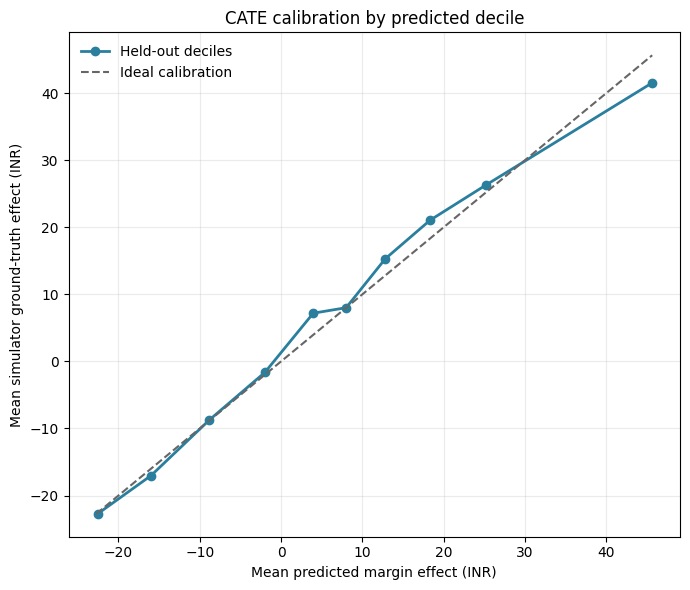

Held-out CATE RMSE: 11.46 INR; correlation: 0.862


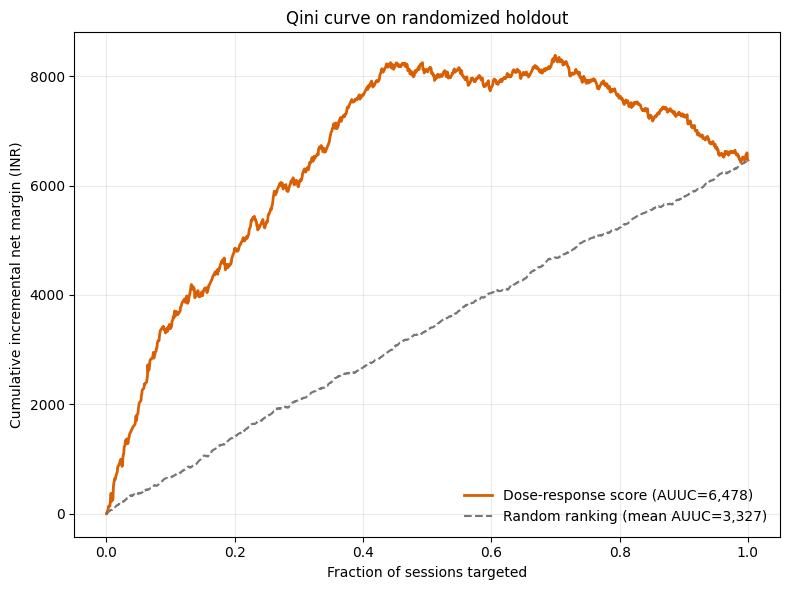

Qini AUUC: 6,478.07; mean random AUUC: 3,326.61


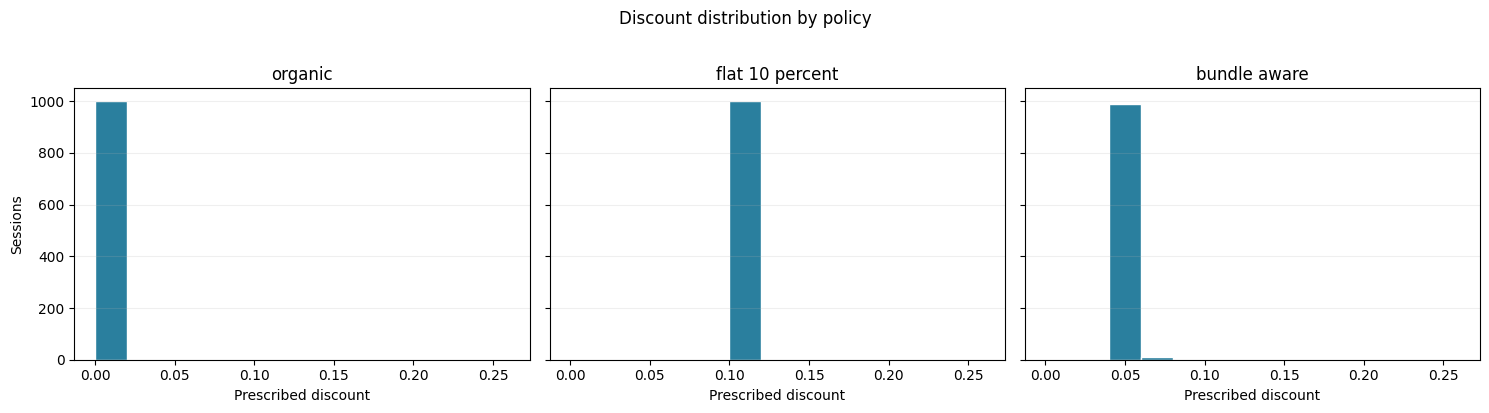

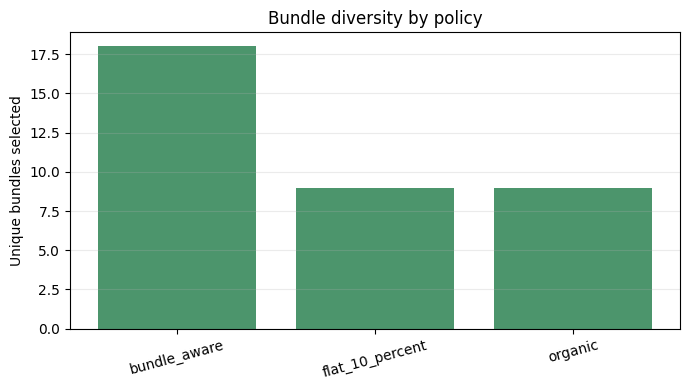

Bundle diversity metrics:
         policy  unique_bundles  bundle_entropy_bits  top_bundle_share
   bundle_aware              18                1.759             0.686
flat_10_percent               9                2.966             0.204
        organic               9                2.966             0.204


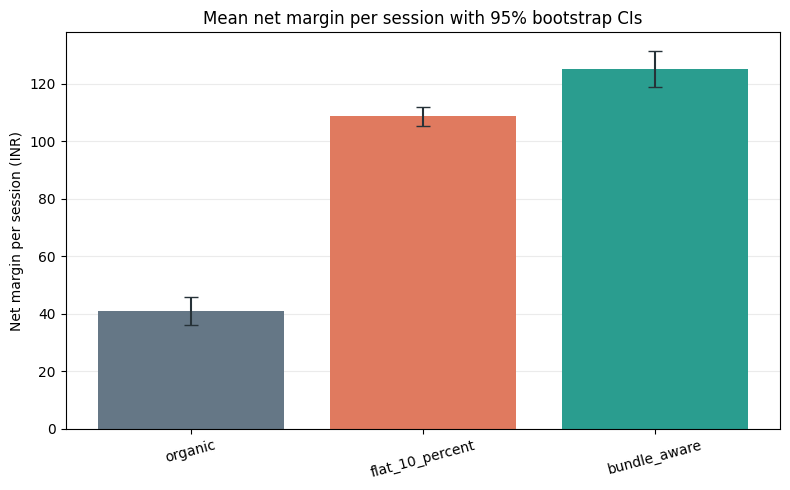

Margin per session and 95% CI:
         policy  mean_margin_per_session  ci_lower  ci_upper
        organic                    40.95     36.02     45.91
flat_10_percent                   108.85    105.22    111.92
   bundle_aware                   125.15    118.80    131.41


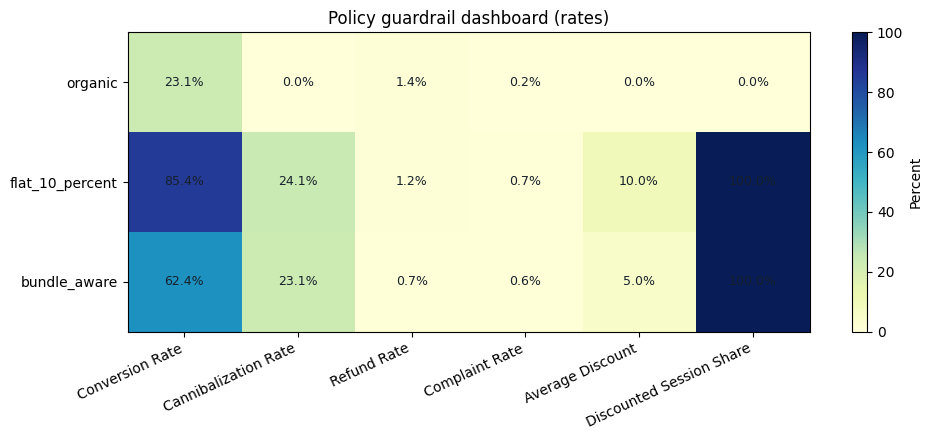

Guardrail metrics (rates):
                 conversion_rate  cannibalization_rate  refund_rate  complaint_rate  average_discount  discounted_session_share
policy                                                                                                                         
organic                     23.1                   0.0          1.4             0.2              0.00                       0.0
flat_10_percent             85.4                  24.1          1.2             0.7             10.00                     100.0
bundle_aware                62.4                  23.1          0.7             0.6              5.02                     100.0


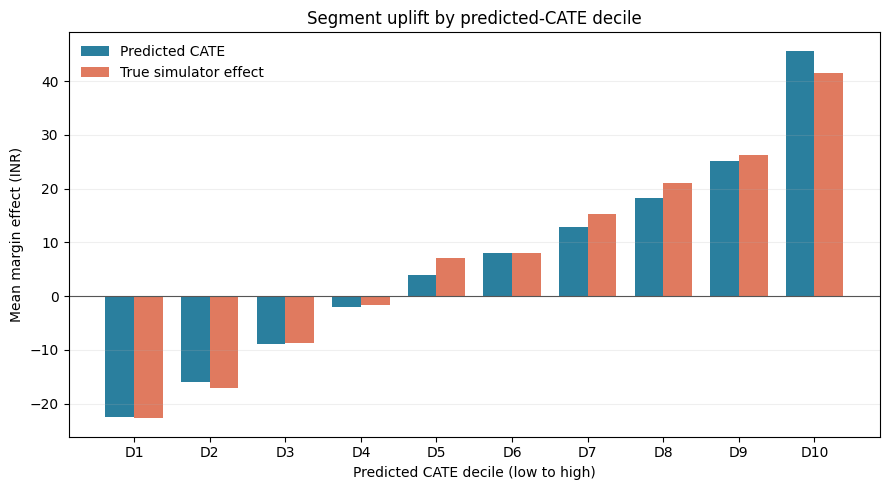

Uplift by predicted-CATE decile:
 cate_decile  sessions  predicted_cate  true_cate
           1        74          -22.55     -22.72
           2        73          -15.98     -17.01
           3        73           -8.80      -8.71
           4        73           -1.99      -1.64
           5        74            3.96       7.19
           6        73            8.01       8.01
           7        73           12.82      15.30
           8        73           18.33      21.06
           9        73           25.17      26.27
          10        74           45.64      41.53


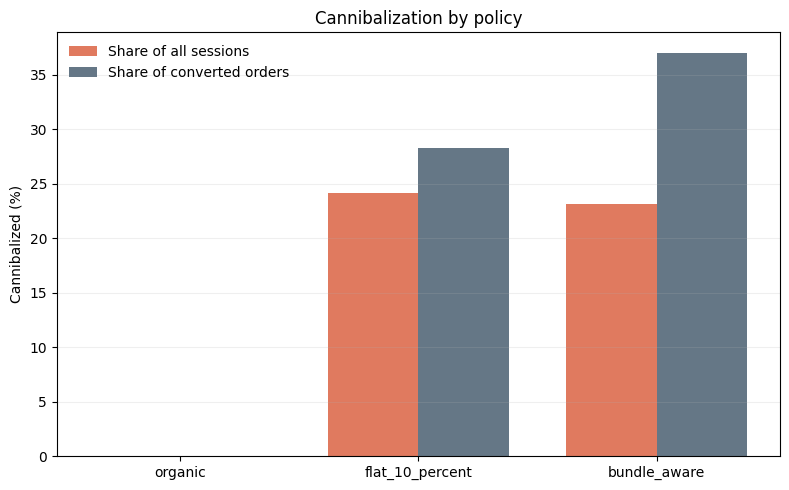

Cannibalization breakdown:
                 cannibalized_sessions_pct  cannibalized_orders_pct  converted_orders
policy                                                                               
organic                                0.0                     0.00               231
flat_10_percent                       24.1                    28.22               854
bundle_aware                          23.1                    37.02               624

Consolidated policy summary:
                 sessions  gross_revenue  net_margin  promotion_cost  conversion_rate  mean_discount  margin_per_session  margin_ci_lower  margin_ci_upper  incremental_margin_vs_organic
policy                                                                                                                                                                                   
organic              1000      160159.14    40954.42            0.00             0.23           0.00               40.95            36.02    

In [9]:
# =============================================================================
# VALIDATION, POLICY DIAGNOSTICS, AND PLOTS
# Loads saved outputs so this section does not regenerate the synthetic dataset.
# =============================================================================
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

DATA_DIR = Path.cwd()
policy_backtest = pd.read_csv(DATA_DIR / "policy_backtest.csv")
ground_truth = pd.read_csv(DATA_DIR / "ground_truth_effects.csv")
randomized_orders = pd.read_csv(DATA_DIR / "orders_randomized.csv")
customers_data = pd.read_csv(DATA_DIR / "customers.csv")
bundles_data = pd.read_csv(DATA_DIR / "bundles.csv")
sessions_data = pd.read_csv(DATA_DIR / "sessions.csv")
restaurants_data = pd.read_csv(DATA_DIR / "restaurants.csv")
items_data = pd.read_csv(DATA_DIR / "items.csv")

required_backtest_columns = {
    "session_id", "policy", "bundle_id", "discount", "net_margin",
    "converted", "is_cannibalized", "refund_flag", "complaint_flag",
}
missing_columns = required_backtest_columns - set(policy_backtest.columns)
if missing_columns:
    raise ValueError(f"policy_backtest.csv is missing columns: {sorted(missing_columns)}")

print("Loaded validation inputs:")
print(f"  Backtest rows: {len(policy_backtest):,}")
print(f"  Randomized order rows: {len(randomized_orders):,}")
print(f"  Ground-truth rows: {len(ground_truth):,}")

# Fit the dose-response model on one part of the randomized sample and evaluate
# predictions only on held-out randomized sessions.
randomized_features = prepare_model_frame(
    randomized_orders, customers_data, bundles_data
)
train_indices, test_indices = train_test_split(
    np.arange(len(randomized_features)),
    test_size=0.2,
    random_state=42,
    stratify=randomized_features["treatment"],
)
validation_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=20,
    random_state=42,
    verbosity=-1,
)
validation_model.fit(
    randomized_features.iloc[train_indices][DOSE_FEATURES],
    randomized_features.iloc[train_indices]["net_margin"],
)
validation_test = randomized_features.iloc[test_indices].copy()
treated_test = validation_test.loc[validation_test["treatment"] == 1].copy()
true_effect_lookup = ground_truth.set_index("session_id")
treated_test["true_cate"] = true_effect_lookup.loc[
    treated_test["session_id"], "tau_margin"
].to_numpy()
observed_dose_features = treated_test[DOSE_FEATURES].copy()
zero_dose_features = observed_dose_features.copy()
zero_dose_features[["basket_discount_depth", "restaurant_offer_depth"]] = 0.0
treated_test["predicted_cate"] = (
    validation_model.predict(observed_dose_features)
    - validation_model.predict(zero_dose_features)
)
cate_rmse = float(np.sqrt(mean_squared_error(
    treated_test["true_cate"], treated_test["predicted_cate"]
)))
cate_correlation = float(np.corrcoef(
    treated_test["true_cate"], treated_test["predicted_cate"]
)[0, 1])

# 1. CATE calibration by predicted-effect decile.
treated_test["cate_decile"] = pd.qcut(
    treated_test["predicted_cate"].rank(method="first"),
    q=10,
    labels=False,
) + 1
calibration = treated_test.groupby("cate_decile", observed=True).agg(
    sessions=("session_id", "size"),
    predicted_cate=("predicted_cate", "mean"),
    true_cate=("true_cate", "mean"),
).reset_index()
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(
    calibration["predicted_cate"], calibration["true_cate"],
    marker="o", linewidth=2, color="#2A7F9E", label="Held-out deciles",
)
calibration_min = min(calibration["predicted_cate"].min(), calibration["true_cate"].min())
calibration_max = max(calibration["predicted_cate"].max(), calibration["true_cate"].max())
ax.plot([calibration_min, calibration_max], [calibration_min, calibration_max],
        linestyle="--", color="#666666", label="Ideal calibration")
ax.set(title="CATE calibration by predicted decile",
       xlabel="Mean predicted margin effect (INR)",
       ylabel="Mean simulator ground-truth effect (INR)")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()
print(f"Held-out CATE RMSE: {cate_rmse:.2f} INR; correlation: {cate_correlation:.3f}")

# 2. Qini curve and AUUC on the randomized held-out sample. Scores use a common
# 10% basket-discount dose; treatment assignment remains randomized, with the
# simulator's assigned dose varying among treated sessions.
all_test = validation_test.copy()
standard_dose = all_test[DOSE_FEATURES].copy()
zero_dose = standard_dose.copy()
standard_dose["basket_discount_depth"] = 0.10
standard_dose["restaurant_offer_depth"] = 0.0
zero_dose[["basket_discount_depth", "restaurant_offer_depth"]] = 0.0
qini_scores = (
    validation_model.predict(standard_dose)
    - validation_model.predict(zero_dose)
)
qini_outcome = all_test["net_margin"].to_numpy(dtype=float)
qini_treatment = all_test["treatment"].to_numpy(dtype=int)

def calculate_qini(outcome, treatment, score):
    order = np.argsort(-score)
    outcome = outcome[order]
    treatment = treatment[order]
    treated_count = np.cumsum(treatment)
    control_count = np.cumsum(1 - treatment)
    treated_outcome = np.cumsum(outcome * treatment)
    control_outcome = np.cumsum(outcome * (1 - treatment))
    curve = treated_outcome - control_outcome * (
        treated_count / np.maximum(control_count, 1)
    )
    fraction = np.arange(1, len(outcome) + 1) / len(outcome)
    x = np.concatenate(([0.0], fraction))
    y = np.concatenate(([0.0], curve))
    return x, y, float(np.trapz(y, x))

qini_x, qini_y, qini_auuc = calculate_qini(
    qini_outcome, qini_treatment, qini_scores
)
random_rng = np.random.default_rng(42)
random_curves = []
random_auucs = []
for _ in range(30):
    random_x, random_y, random_auuc = calculate_qini(
        qini_outcome, qini_treatment,
        random_rng.normal(size=len(qini_outcome)),
    )
    random_curves.append(random_y)
    random_auucs.append(random_auuc)
mean_random_curve = np.mean(random_curves, axis=0)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(qini_x, qini_y, color="#D95F02", linewidth=2,
        label=f"Dose-response score (AUUC={qini_auuc:,.0f})")
ax.plot(qini_x, mean_random_curve, color="#777777", linestyle="--",
        label=f"Random ranking (mean AUUC={np.mean(random_auucs):,.0f})")
ax.set(title="Qini curve on randomized holdout",
       xlabel="Fraction of sessions targeted",
       ylabel="Cumulative incremental net margin (INR)")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()
print(f"Qini AUUC: {qini_auuc:,.2f}; mean random AUUC: {np.mean(random_auucs):,.2f}")

# 3. Discount distribution by policy.
policy_order = ["organic", "flat_10_percent", "bundle_aware"]
policy_order = [name for name in policy_order if name in policy_backtest["policy"].unique()]
fig, axes = plt.subplots(1, len(policy_order), figsize=(5 * len(policy_order), 4), sharey=True)
if len(policy_order) == 1:
    axes = [axes]
for ax, policy_name in zip(axes, policy_order):
    discounts = policy_backtest.loc[
        policy_backtest["policy"] == policy_name, "discount"
    ]
    ax.hist(discounts, bins=np.linspace(0, 0.26, 14), color="#2A7F9E", edgecolor="white")
    ax.set(title=policy_name.replace("_", " "), xlabel="Prescribed discount")
    ax.grid(axis="y", alpha=0.2)
axes[0].set_ylabel("Sessions")
fig.suptitle("Discount distribution by policy", y=1.02)
fig.tight_layout()
plt.show()

# 4. Bundle diversity by policy: unique bundle count and normalized entropy.
bundle_diversity_rows = []
for policy_name, subset in policy_backtest.groupby("policy"):
    bundle_shares = subset["bundle_id"].value_counts(normalize=True)
    entropy = float(-(bundle_shares * np.log2(bundle_shares)).sum())
    bundle_diversity_rows.append({
        "policy": policy_name,
        "unique_bundles": int(subset["bundle_id"].nunique()),
        "bundle_entropy_bits": entropy,
        "top_bundle_share": float(bundle_shares.iloc[0]),
    })
bundle_diversity = pd.DataFrame(bundle_diversity_rows).sort_values("policy")
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(bundle_diversity["policy"], bundle_diversity["unique_bundles"], color="#4C956C")
ax.set(title="Bundle diversity by policy", ylabel="Unique bundles selected")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()
print("Bundle diversity metrics:")
print(bundle_diversity.round(3).to_string(index=False))

# 5. Mean margin per session with paired session bootstrap confidence intervals.
margin_matrix = policy_backtest.pivot(
    index="session_id", columns="policy", values="net_margin"
)[policy_order].dropna()
margin_values = margin_matrix.to_numpy()
bootstrap_rng = np.random.default_rng(42)
bootstrap_indices = bootstrap_rng.integers(
    0, len(margin_values), size=(1000, len(margin_values))
)
bootstrap_policy_means = margin_values[bootstrap_indices].mean(axis=1)
margin_means = margin_values.mean(axis=0)
margin_lows, margin_highs = np.percentile(bootstrap_policy_means, [2.5, 97.5], axis=0)
margin_ci = pd.DataFrame({
    "policy": policy_order,
    "mean_margin_per_session": margin_means,
    "ci_lower": margin_lows,
    "ci_upper": margin_highs,
})
fig, ax = plt.subplots(figsize=(8, 5))
errors = np.vstack([margin_means - margin_lows, margin_highs - margin_means])
ax.bar(policy_order, margin_means, color=["#657786", "#E07A5F", "#2A9D8F"], zorder=2)
ax.errorbar(np.arange(len(policy_order)), margin_means, yerr=errors,
            fmt="none", ecolor="#263238", capsize=5, zorder=3)
ax.set(title="Mean net margin per session with 95% bootstrap CIs",
       ylabel="Net margin per session (INR)")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.25, zorder=0)
fig.tight_layout()
plt.show()
print("Margin per session and 95% CI:")
print(margin_ci.round(2).to_string(index=False))

# 6. Guardrail dashboard heatmap. Values are rates (percent); lower is not
# universally better for every metric, so interpret each column separately.
guardrail = policy_backtest.groupby("policy").agg(
    conversion_rate=("converted", "mean"),
    cannibalization_rate=("is_cannibalized", "mean"),
    refund_rate=("refund_flag", "mean"),
    complaint_rate=("complaint_flag", "mean"),
    average_discount=("discount", "mean"),
).reindex(policy_order)
guardrail["discounted_session_share"] = policy_backtest.assign(
    discounted=policy_backtest["discount"] > 0
).groupby("policy")["discounted"].mean().reindex(policy_order)
heatmap_values = guardrail.to_numpy() * 100
fig, ax = plt.subplots(figsize=(10, 4.5))
image = ax.imshow(heatmap_values, aspect="auto", cmap="YlGnBu", vmin=0)
ax.set_xticks(np.arange(len(guardrail.columns)),
              labels=[name.replace("_", " ").title() for name in guardrail.columns],
              rotation=25, ha="right")
ax.set_yticks(np.arange(len(guardrail.index)), labels=guardrail.index)
for row_index in range(heatmap_values.shape[0]):
    for column_index in range(heatmap_values.shape[1]):
        ax.text(column_index, row_index, f"{heatmap_values[row_index, column_index]:.1f}%",
                ha="center", va="center", color="#17212B", fontsize=9)
ax.set_title("Policy guardrail dashboard (rates)")
fig.colorbar(image, ax=ax, label="Percent")
fig.tight_layout()
plt.show()
print("Guardrail metrics (rates):")
print((guardrail * 100).round(2).to_string())

# 7. Segment-level uplift by deciles of predicted CATE (same held-out treated set).
fig, ax = plt.subplots(figsize=(9, 5))
segment_positions = np.arange(len(calibration))
bar_width = 0.38
ax.bar(segment_positions - bar_width / 2, calibration["predicted_cate"],
       width=bar_width, color="#2A7F9E", label="Predicted CATE")
ax.bar(segment_positions + bar_width / 2, calibration["true_cate"],
       width=bar_width, color="#E07A5F", label="True simulator effect")
ax.set_xticks(segment_positions, labels=[f"D{int(value)}" for value in calibration["cate_decile"]])
ax.set(title="Segment uplift by predicted-CATE decile",
       xlabel="Predicted CATE decile (low to high)", ylabel="Mean margin effect (INR)")
ax.axhline(0, color="#555555", linewidth=0.8)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()
print("Uplift by predicted-CATE decile:")
print(calibration.round(2).to_string(index=False))

# 8. Cannibalization breakdown overall and conditional on a completed order.
cannibalization_rows = []
for policy_name, subset in policy_backtest.groupby("policy"):
    converted_subset = subset.loc[subset["converted"] == 1]
    cannibalization_rows.append({
        "policy": policy_name,
        "cannibalized_sessions_pct": 100 * subset["is_cannibalized"].mean(),
        "cannibalized_orders_pct": (
            100 * converted_subset["is_cannibalized"].mean()
            if len(converted_subset) else 0.0
        ),
        "converted_orders": len(converted_subset),
    })
cannibalization_summary = pd.DataFrame(cannibalization_rows).set_index("policy").reindex(policy_order)
fig, ax = plt.subplots(figsize=(8, 5))
plot_positions = np.arange(len(policy_order))
ax.bar(plot_positions - bar_width / 2,
       cannibalization_summary["cannibalized_sessions_pct"],
       width=bar_width, color="#E07A5F", label="Share of all sessions")
ax.bar(plot_positions + bar_width / 2,
       cannibalization_summary["cannibalized_orders_pct"],
       width=bar_width, color="#657786", label="Share of converted orders")
ax.set_xticks(plot_positions, labels=policy_order)
ax.set(title="Cannibalization by policy", ylabel="Cannibalized (%)")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()
print("Cannibalization breakdown:")
print(cannibalization_summary.round(2).to_string())

# 9. Consolidated summary with intervals and a data-driven interpretation.
policy_summary = policy_backtest.groupby("policy").agg(
    sessions=("session_id", "count"),
    gross_revenue=("gross_revenue", "sum"),
    net_margin=("net_margin", "sum"),
    promotion_cost=("promo_cost", "sum"),
    conversion_rate=("converted", "mean"),
    mean_discount=("discount", "mean"),
).reindex(policy_order)
policy_summary["margin_per_session"] = margin_means
policy_summary["margin_ci_lower"] = margin_lows
policy_summary["margin_ci_upper"] = margin_highs
organic_margin = policy_summary.loc["organic", "net_margin"]
policy_summary["incremental_margin_vs_organic"] = policy_summary["net_margin"] - organic_margin
print("\nConsolidated policy summary:")
print(policy_summary.round(2).to_string())
best_policy = policy_summary["net_margin"].idxmax()
flat_policy = "flat_10_percent"
bundle_policy = "bundle_aware"
if best_policy == bundle_policy:
    print(
        "Interpretation: Bundle-aware targeting has the highest simulated total margin. "
        f"Its mean margin/session is ₹{policy_summary.loc[bundle_policy, 'margin_per_session']:.2f} "
        f"(95% CI ₹{margin_lows[policy_order.index(bundle_policy)]:.2f}–"
        f"₹{margin_highs[policy_order.index(bundle_policy)]:.2f}), and its promotion spend is "
        f"₹{policy_summary.loc[bundle_policy, 'promotion_cost']:,.0f} versus "
        f"₹{policy_summary.loc[flat_policy, 'promotion_cost']:,.0f} for flat 10%."
    )
else:
    print(f"Interpretation: {best_policy} has the highest simulated total margin in this run.")
print(
    "Validation caveat: all outcomes and ground truth are synthetic; Qini and policy "
    "rankings are diagnostics within this simulator, not production causal evidence."
)

In [7]:
# =============================================================================
# FOLLOW-UP DIAGNOSTICS: QINI, STRATEGY CONCENTRATION, AND DIVERSITY CONSTRAINT
# Reads generated CSVs from the notebook-relative output directory.
# =============================================================================
from pathlib import Path

import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split

candidate_dirs = [Path("."), Path("data")]
DATA_DIR = next(
    (directory for directory in candidate_dirs if (directory / "policy_backtest.csv").exists()),
    candidate_dirs[0],
)
if not (DATA_DIR / "policy_backtest.csv").exists():
    raise FileNotFoundError(f"Could not find policy_backtest.csv in {candidate_dirs}.")

policy_backtest = pd.read_csv(DATA_DIR / "policy_backtest.csv")
randomized_orders = pd.read_csv(DATA_DIR / "orders_randomized.csv")
ground_truth = pd.read_csv(DATA_DIR / "ground_truth_effects.csv")
customers_data = pd.read_csv(DATA_DIR / "customers.csv")
bundles_data = pd.read_csv(DATA_DIR / "bundles.csv")
sessions_data = pd.read_csv(DATA_DIR / "sessions.csv")

customer_features = [
    "locality_affluence", "historical_avg_spend", "budget_std_dev",
    "paycheck_expansion_ratio", "basket_discount_sensitivity",
    "restaurant_offer_sensitivity", "new_food_propensity", "loyalty_score",
]
session_features = ["day_of_month", "day_of_week", "is_paycheck_week"]
context_features = [
    "dp_breakfast", "dp_lunch", "dp_dinner", "dp_late_night",
    "wx_clear", "wx_rain", "wx_extreme",
]
base_features = customer_features + session_features + context_features
bundle_features = base_features + [
    "bundle_price", "bundle_cuisine_match", "bundle_novelty_score",
    "bundle_price_fit", "bundle_price_ratio", "bundle_margin_pct",
]
dose_features = bundle_features + ["basket_discount_depth", "restaurant_offer_depth"]

model_frame = prepare_model_frame(randomized_orders, customers_data, bundles_data)
train_indices, test_indices = train_test_split(
    np.arange(len(model_frame)),
    test_size=0.2,
    random_state=42,
    stratify=model_frame["treatment"],
)
diagnostic_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=20,
    random_state=42,
    verbosity=-1,
)
diagnostic_model.fit(
    model_frame.iloc[train_indices][dose_features],
    model_frame.iloc[train_indices]["net_margin"],
)
holdout = model_frame.iloc[test_indices].copy()
standard_dose = holdout[dose_features].copy()
zero_dose = standard_dose.copy()
standard_dose["basket_discount_depth"] = 0.10
standard_dose["restaurant_offer_depth"] = 0.0
zero_dose[["basket_discount_depth", "restaurant_offer_depth"]] = 0.0
uplift_scores = (
    diagnostic_model.predict(standard_dose)
    - diagnostic_model.predict(zero_dose)
)


def qini_curve(outcome, treatment, score):
    order = np.argsort(-score)
    outcome = np.asarray(outcome, dtype=float)[order]
    treatment = np.asarray(treatment, dtype=int)[order]
    treated_count = np.cumsum(treatment)
    control_count = np.cumsum(1 - treatment)
    treated_outcome = np.cumsum(outcome * treatment)
    control_outcome = np.cumsum(outcome * (1 - treatment))
    curve = treated_outcome - control_outcome * (
        treated_count / np.maximum(control_count, 1)
    )
    fraction = np.arange(1, len(outcome) + 1) / len(outcome)
    return np.concatenate(([0.0], fraction)), np.concatenate(([0.0], curve))


def uplift_at_fraction(outcome, treatment, score, fraction):
    count = max(1, int(np.ceil(len(score) * fraction)))
    selected = np.argsort(-score)[:count]
    treated = np.asarray(treatment)[selected] == 1
    control = ~treated
    if not treated.any() or not control.any():
        return np.nan
    selected_outcomes = np.asarray(outcome, dtype=float)[selected]
    return float(selected_outcomes[treated].mean() - selected_outcomes[control].mean())


random_rng = np.random.default_rng(42)
qini_rows = []
for metric in ("net_margin", "gross_revenue", "converted"):
    outcomes = holdout[metric].to_numpy(dtype=float)
    treatment = holdout["treatment"].to_numpy(dtype=int)
    x, y = qini_curve(outcomes, treatment, uplift_scores)
    model_auuc = float(np.trapz(y, x))
    random_auucs = []
    random_uplifts = {0.10: [], 0.20: []}
    for _ in range(30):
        random_scores = random_rng.normal(size=len(outcomes))
        random_x, random_y = qini_curve(outcomes, treatment, random_scores)
        random_auucs.append(float(np.trapz(random_y, random_x)))
        for fraction in random_uplifts:
            random_uplifts[fraction].append(
                uplift_at_fraction(outcomes, treatment, random_scores, fraction)
            )
    random_auuc = float(np.mean(random_auucs))
    qini_rows.append({
        "outcome": metric,
        "mean_outcome": float(np.mean(outcomes)),
        "model_auuc": model_auuc,
        "random_mean_auuc": random_auuc,
        "auuc_delta_vs_random": model_auuc - random_auuc,
        "delta_pct_of_abs_random": (
            100 * (model_auuc - random_auuc) / abs(random_auuc)
            if random_auuc else np.nan
        ),
        "uplift_at_10pct": uplift_at_fraction(outcomes, treatment, uplift_scores, 0.10),
        "random_uplift_at_10pct": float(np.nanmean(random_uplifts[0.10])),
        "uplift_at_20pct": uplift_at_fraction(outcomes, treatment, uplift_scores, 0.20),
        "random_uplift_at_20pct": float(np.nanmean(random_uplifts[0.20])),
    })
qini_diagnostics = pd.DataFrame(qini_rows)
print(f"Diagnostic inputs loaded from: {DATA_DIR}")
print("Qini and top-k uplift on randomized holdout (30 random-ranking draws):")
print(qini_diagnostics.round(3).to_string(index=False))
margin_result = qini_diagnostics.set_index("outcome").loc["net_margin"]
print(
    f"\nMargin interpretation: held-out mean margin is {margin_result['mean_outcome']:.2f}, "
    f"so negative AUUC is not explained by a negative mean outcome. AUUC improves by "
    f"{margin_result['auuc_delta_vs_random']:.2f} vs random, but top-10% uplift is "
    f"{margin_result['uplift_at_10pct']:.2f} vs {margin_result['random_uplift_at_10pct']:.2f} "
    "for random ranking; the margin targeting result is not uniformly positive."
)

if "strategy" in policy_backtest.columns:
    strategy_distribution = pd.crosstab(
        policy_backtest["policy"], policy_backtest["strategy"], normalize="index"
    ).mul(100).round(2)
    print("\nSelected strategy distribution by policy (% of sessions):")
    print(strategy_distribution.to_string())
else:
    print("\nNo 'strategy' column in policy_backtest.csv; strategy distribution unavailable.")

concentration_rows = []
for policy_name, subset in policy_backtest.groupby("policy"):
    shares = subset["bundle_id"].value_counts(normalize=True)
    concentration_rows.append({
        "policy": policy_name,
        "unique_bundles": int(subset["bundle_id"].nunique()),
        "top_bundle_share_pct": 100 * float(shares.iloc[0]),
        "entropy_bits": float(-(shares * np.log2(shares)).sum()),
    })
concentration = pd.DataFrame(concentration_rows).sort_values("policy")
print("\nObserved bundle concentration:")
print(concentration.round(3).to_string(index=False))

organic = policy_backtest.loc[policy_backtest["policy"] == "organic"]
organic_mean_margin = organic["net_margin"].mean()
adjusted_rows = []
for policy_name, subset in policy_backtest.groupby("policy"):
    cannibalization_rate = float(subset["is_cannibalized"].mean())
    incremental_margin_per_session = float(subset["net_margin"].mean() - organic_mean_margin)
    adjusted_rows.append({
        "policy": policy_name,
        "cannibalization_rate_pct": 100 * cannibalization_rate,
        "incremental_margin_per_session": incremental_margin_per_session,
        "heuristic_adjusted_lift_per_session": (
            (1 - cannibalization_rate) * incremental_margin_per_session
        ),
        "promo_cost_on_cannibalized_orders": float(
            (subset["promo_cost"] * subset["is_cannibalized"]).sum()
        ),
    })
cannibalization_adjusted = pd.DataFrame(adjusted_rows).sort_values("policy")
print("\nCannibalization and adjusted margin diagnostic:")
print(cannibalization_adjusted.round(3).to_string(index=False))
print(
    "The adjusted lift is a requested sensitivity heuristic, not a causal estimate; "
    "the simulator's cannibalization flag is generated by its own structural rule."
)


def make_candidate_rows(customer, session, bundles, max_candidates=5):
    expected_spend = float(customer["historical_avg_spend"])
    budget = float(customer["budget_std_dev"])
    lower = max(50.0, (expected_spend - budget) * 0.5)
    upper = (expected_spend + 1.5 * budget) * 1.5
    pool = bundles.loc[bundles["base_price"].between(lower, upper)].copy()
    if len(pool) < max_candidates:
        pool = bundles.copy()
    cuisine = pool["cuisine"].map(
        lambda value: customer.get(f"pref_{value}", 0.05)
    ).to_numpy()
    prices = pool["base_price"].to_numpy(dtype=float)
    price_fit = np.exp(-np.abs(prices - expected_spend) / (expected_spend + 1e-5))
    novelty = 1 + float(customer["new_food_propensity"]) * pool["has_new_item"].astype(float).to_numpy()
    margin = (
        (pool["base_price"] - pool["base_cost"])
        / pool["base_price"].clip(lower=1e-5)
    ).to_numpy()
    strategy_scores = {
        "familiar": cuisine * price_fit,
        "exploratory": cuisine * novelty,
        "value": margin * price_fit,
        "premium": price_fit * prices / (expected_spend + 1e-5),
    }
    selected, seen = [], set()
    for strategy, values in strategy_scores.items():
        for index in np.argsort(-values):
            bundle = pool.iloc[index]
            bundle_id = int(bundle["bundle_id"])
            if bundle_id in seen:
                continue
            selected.append((bundle, strategy))
            seen.add(bundle_id)
            break
        if len(selected) >= max_candidates:
            break
    return selected


def candidate_feature_row(customer, session, bundle, discount):
    price = float(bundle["base_price"])
    spend = float(customer["historical_avg_spend"])
    row = {
        feature: float(session.get(feature, customer.get(feature, 0)))
        for feature in base_features
    }
    row.update({
        "bundle_price": price,
        "bundle_cuisine_match": float(customer.get(f"pref_{bundle['cuisine']}", 0.05)),
        "bundle_novelty_score": float(customer["new_food_propensity"]) * float(bundle["has_new_item"]),
        "bundle_price_fit": float(np.exp(-abs(price - spend) / (spend + 1e-5))),
        "bundle_price_ratio": price / (spend + 1e-5),
        "bundle_margin_pct": (price - float(bundle["base_cost"])) / (price + 1e-5),
        "basket_discount_depth": discount,
        "restaurant_offer_depth": 0.0,
    })
    for value in ("breakfast", "lunch", "dinner", "late_night"):
        row[f"dp_{value}"] = float(session.get("daypart") == value)
    for value in ("clear", "rain", "extreme"):
        row[f"wx_{value}"] = float(session.get("weather") == value)
    return row


sample_sessions = sessions_data.sample(
    n=min(300, len(sessions_data)), random_state=42
).reset_index(drop=True)
customer_lookup = customers_data.set_index("customer_id")
recommendations = []
discount_grid = np.linspace(0.0, 0.25, 11)
for session in sample_sessions.to_dict("records"):
    customer = customer_lookup.loc[session["customer_id"]]
    candidates = make_candidate_rows(customer, session, bundles_data)
    candidate_options = []
    for bundle, strategy in candidates:
        rows = [candidate_feature_row(customer, session, bundle, float(d)) for d in discount_grid]
        prediction = diagnostic_model.predict(pd.DataFrame(rows)[dose_features])
        uplift_by_discount = prediction - prediction[0]
        best_discount_index = int(np.argmax(uplift_by_discount))
        candidate_options.append({
            "bundle_id": int(bundle["bundle_id"]),
            "predicted_incremental_margin": float(uplift_by_discount[best_discount_index]),
            "discount": float(discount_grid[best_discount_index]),
            "strategy": strategy,
        })
    candidate_options.sort(
        key=lambda option: option["predicted_incremental_margin"], reverse=True
    )
    recommendations.append(candidate_options)

unconstrained = [options[0] for options in recommendations]
cap_per_bundle = int(np.ceil(0.25 * len(recommendations)))
usage = {}
constrained = []
for options in recommendations:
    available = next(
        (option for option in options if usage.get(option["bundle_id"], 0) < cap_per_bundle),
        options[0],
    )
    constrained.append(available)
    usage[available["bundle_id"]] = usage.get(available["bundle_id"], 0) + 1


def allocation_stats(label, assignments):
    shares = pd.Series([item["bundle_id"] for item in assignments]).value_counts(normalize=True)
    return {
        "allocation": label,
        "sessions": len(assignments),
        "unique_bundles": int(shares.size),
        "top_bundle_share_pct": 100 * float(shares.iloc[0]),
        "mean_predicted_incremental_margin": float(np.mean([
            item["predicted_incremental_margin"] for item in assignments
        ])),
    }


diversity_check = pd.DataFrame([
    allocation_stats("unconstrained", unconstrained),
    allocation_stats("25pct_bundle_cap", constrained),
])
print("\nDiversity-constrained candidate check (300-session sample; model predictions only):")
print(diversity_check.round(3).to_string(index=False))


Diagnostic inputs loaded from: .
Qini and top-k uplift on randomized holdout (30 random-ranking draws):
      outcome  mean_outcome  model_auuc  random_mean_auuc  auuc_delta_vs_random  delta_pct_of_abs_random  uplift_at_10pct  random_uplift_at_10pct  uplift_at_20pct  random_uplift_at_20pct
   net_margin        19.856    6478.069          3326.610              3151.459                   94.735           47.822                   9.246           31.403                   9.825
gross_revenue       233.059  127444.063        108394.416             19049.647                   17.574          491.796                 282.414          410.032                 290.665
    converted         0.529     249.104           230.636                18.468                    8.007            0.759                   0.617            0.695                   0.626

Margin interpretation: held-out mean margin is 19.86, so negative AUUC is not explained by a negative mean outcome. AUUC improves by 3151.46 vs ran

In [8]:
# Inputs shared by the robustness extensions below.
truth = ground_truth.copy()
restaurants_data = pd.read_csv(DATA_DIR / "restaurants.csv")
if "restaurant_id" not in model_frame.columns:
    model_frame = model_frame.merge(
        bundles_data[["bundle_id", "restaurant_id"]],
        on="bundle_id", how="left",
    )


In [9]:
# =============================================================================
# ROBUSTNESS: ALTERNATIVE TARGET, T-LEARNER, CV, ORACLE, AND MULTI-SEED CHECK
# All expected-effect comparisons use the calibrated 25% base conversion rate.
# =============================================================================
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold


def expected_margin_at_dose(row, discount, base_rate=CALIBRATED_BASE_CONVERSION_RATE):
    daypart_factor = {
        "breakfast": 0.85, "lunch": 1.10, "dinner": 1.35, "late_night": 0.95,
    }.get(row["daypart"], 1.0)
    weather_factor = {"clear": 1.0, "rain": 1.15, "extreme": 1.30}.get(row["weather"], 1.0)
    paycheck_factor = float(row["paycheck_expansion_ratio"]) if int(row["is_paycheck_week"]) else 1.0
    demand = float(row["historical_avg_spend"]) * paycheck_factor * daypart_factor * weather_factor
    quantity = int(row.get("quantity", 1))
    price = float(row["bundle_price"]) * quantity
    barrier = np.exp(-max(0.0, price - demand) / (float(row["budget_std_dev"]) + 1e-5))
    p_organic = float(np.clip(base_rate * barrier, 0.05, 0.95))
    sensitivity = float(row["basket_discount_sensitivity"]) * 1.5 + float(row["restaurant_offer_sensitivity"])
    response = sensitivity * np.log1p(discount * 10.0)
    p_convert = (
        float(np.clip((base_rate + response) * barrier, 0.05, 0.98))
        if discount > 0 else p_organic
    )
    revenue = price * (1.0 + response * 0.15)
    fulfillment = 30.0 + float(row["fulfillment_distance_km"]) * 6.0 + weather_factor * 10.0
    margin_if_converted = revenue * (1.0 - discount - 0.65) - fulfillment
    return p_convert * margin_if_converted


model_context = model_frame.merge(
    restaurants_data[["restaurant_id", "fulfillment_distance_km"]],
    on="restaurant_id", how="left",
)
common_dose_truth = np.asarray([
    expected_margin_at_dose(row, 0.10) - expected_margin_at_dose(row, 0.0)
    for row in model_context.to_dict("records")
])
test_truth = common_dose_truth[test_indices]

train_frame = model_frame.iloc[train_indices]
test_frame = model_frame.iloc[test_indices]
conversion_model = LGBMClassifier(
    n_estimators=300, learning_rate=0.03, num_leaves=31,
    min_child_samples=20, random_state=42, verbosity=-1,
)
conversion_model.fit(train_frame[dose_features], train_frame["converted"])
converted_train = train_frame.loc[train_frame["converted"] == 1]
conditional_margin_model = LGBMRegressor(
    n_estimators=300, learning_rate=0.03, num_leaves=31,
    min_child_samples=20, random_state=43, verbosity=-1,
)
conditional_margin_model.fit(converted_train[dose_features], converted_train["net_margin"])
positive_class = int(np.flatnonzero(conversion_model.classes_ == 1)[0])


def expected_margin_prediction(features):
    return (
        conversion_model.predict_proba(features)[:, positive_class]
        * conditional_margin_model.predict(features)
    )


standard_test = test_frame[dose_features].copy()
zero_test = standard_test.copy()
standard_test["basket_discount_depth"] = 0.10
standard_test["restaurant_offer_depth"] = 0.0
zero_test[["basket_discount_depth", "restaurant_offer_depth"]] = 0.0
decomposed_scores = expected_margin_prediction(standard_test) - expected_margin_prediction(zero_test)

control_train = train_frame.loc[train_frame["treatment"] == 0]
treated_train = train_frame.loc[train_frame["treatment"] == 1]
t_control = LGBMRegressor(
    n_estimators=300, learning_rate=0.03, num_leaves=31,
    min_child_samples=20, random_state=44, verbosity=-1,
)
t_treated = LGBMRegressor(
    n_estimators=300, learning_rate=0.03, num_leaves=31,
    min_child_samples=20, random_state=45, verbosity=-1,
)
t_control.fit(control_train[bundle_features], control_train["net_margin"])
t_treated.fit(treated_train[bundle_features], treated_train["net_margin"])
t_learner_scores = (
    t_treated.predict(test_frame[bundle_features])
    - t_control.predict(test_frame[bundle_features])
)

ranker_rows = []
for name, scores in (
    ("direct_dose_model", uplift_scores),
    ("conversion_x_conditional_margin", decomposed_scores),
    ("binary_t_learner", t_learner_scores),
):
    selected = np.argsort(-scores)[:max(1, int(np.ceil(0.10 * len(scores))))]
    ranker_rows.append({
        "ranker": name,
        "cate_correlation": float(np.corrcoef(test_truth, scores)[0, 1]),
        "true_effect_top_10pct": float(test_truth[selected].mean()),
    })
oracle_selected = np.argsort(-test_truth)[:max(1, int(np.ceil(0.10 * len(test_truth))))]
ranker_rows.append({
    "ranker": "oracle_true_effect",
    "cate_correlation": 1.0,
    "true_effect_top_10pct": float(test_truth[oracle_selected].mean()),
})
ranker_comparison = pd.DataFrame(ranker_rows)
print("Holdout ranker comparison (common 10% dose; exact expected-margin truth):")
print(ranker_comparison.round(3).to_string(index=False))

fold_rows = []
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold_number, (fold_train, fold_test) in enumerate(
    folds.split(model_frame, model_frame["treatment"]), start=1
):
    fold_model = LGBMRegressor(
        n_estimators=200, learning_rate=0.03, num_leaves=31,
        min_child_samples=20, random_state=100 + fold_number, verbosity=-1,
    )
    fold_model.fit(
        model_frame.iloc[fold_train][dose_features],
        model_frame.iloc[fold_train]["net_margin"],
    )
    features = model_frame.iloc[fold_test][dose_features].copy()
    zero_features = features.copy()
    features["basket_discount_depth"] = 0.10
    features["restaurant_offer_depth"] = 0.0
    zero_features[["basket_discount_depth", "restaurant_offer_depth"]] = 0.0
    scores = fold_model.predict(features) - fold_model.predict(zero_features)
    fold_rows.append({
        "fold": fold_number,
        "cate_correlation": float(np.corrcoef(common_dose_truth[fold_test], scores)[0, 1]),
    })
fold_validation = pd.DataFrame(fold_rows)
print("\nFive-fold CATE correlation against exact 10% dose effect:")
print(fold_validation.round(3).to_string(index=False))
print(
    f"Mean +/- SD: {fold_validation['cate_correlation'].mean():.3f} +/- "
    f"{fold_validation['cate_correlation'].std():.3f}"
)

seed_rows = []
for seed in (42, 123, 456, 789, 1011):
    cfg = Config(n_customers=250, backtest_sessions=250, seed=seed)
    rng = np.random.default_rng(seed)
    seed_customers = generate_customers(cfg, rng)
    seed_restaurants, _, seed_bundles = generate_catalog(cfg, rng)
    seed_sessions = generate_sessions(seed_customers, cfg, rng)
    _, seed_randomized, seed_truth = generate_experiments(
        seed_customers, seed_sessions, seed_bundles, seed_restaurants, cfg, rng,
        base_conversion_rate=CALIBRATED_BASE_CONVERSION_RATE,
        analytic_truth=True,
    )
    seed_features = prepare_model_frame(seed_randomized, seed_customers, seed_bundles)
    seed_model, seed_rmse, seed_correlation = validate_dose_model(seed_features, seed_truth, seed)
    seed_backtest = run_policy_backtest(
        seed_sessions, seed_customers, seed_bundles, seed_restaurants, seed_model, cfg,
        base_conversion_rate=CALIBRATED_BASE_CONVERSION_RATE,
    )
    seed_summary = seed_backtest.groupby("policy").agg(
        mean_margin=("net_margin", "mean"),
        cannibalization_rate=("is_cannibalized", "mean"),
        unique_bundles=("bundle_id", "nunique"),
    )
    seed_top_share = seed_backtest.groupby("policy")["bundle_id"].apply(
        lambda values: values.value_counts(normalize=True).iloc[0]
    )
    seed_rows.append({
        "seed": seed,
        "cate_rmse": seed_rmse,
        "cate_correlation": seed_correlation,
        "bundle_aware_margin_lift_vs_organic": (
            seed_summary.loc["bundle_aware", "mean_margin"]
            - seed_summary.loc["organic", "mean_margin"]
        ),
        "bundle_aware_cannibalization_pct": 100 * seed_summary.loc["bundle_aware", "cannibalization_rate"],
        "bundle_aware_unique_bundles": seed_summary.loc["bundle_aware", "unique_bundles"],
        "bundle_aware_top_bundle_share_pct": 100 * seed_top_share.loc["bundle_aware"],
    })
seed_validation = pd.DataFrame(seed_rows)
print("\nFive-seed compact simulator validation (250 customers and backtest sessions per seed):")
print(seed_validation.round(3).to_string(index=False))
print("Mean +/- SD:")
print(seed_validation.drop(columns="seed").agg(["mean", "std"]).round(3).to_string())

backtest_context = policy_backtest.merge(
    sessions_data[["session_id", "customer_id", "daypart", "weather", "is_paycheck_week"]],
    on="session_id", how="left",
).merge(
    customers_data[[
        "customer_id", "historical_avg_spend", "budget_std_dev",
        "paycheck_expansion_ratio", "basket_discount_sensitivity",
        "restaurant_offer_sensitivity",
    ]], on="customer_id", how="left",
).merge(
    bundles_data[["bundle_id", "base_price", "restaurant_id"]],
    on="bundle_id", how="left",
).merge(
    restaurants_data[["restaurant_id", "fulfillment_distance_km"]],
    on="restaurant_id", how="left",
)
backtest_context["bundle_price"] = backtest_context["base_price"]
sensitivity_rows = []
for base_rate in (0.60, CALIBRATED_BASE_CONVERSION_RATE):
    outcomes = []
    for row in backtest_context.to_dict("records"):
        discount = float(row["discount"])
        margin = expected_margin_at_dose(row, discount, base_rate)
        organic_margin = expected_margin_at_dose(row, 0.0, base_rate)
        outcomes.append({
            "policy": row["policy"],
            "expected_margin": margin,
            "expected_promo_cost": max(0.0, float(row["bundle_price"]) * discount),
            "expected_cannibalized_promo_cost": (
                max(0.0, float(row["bundle_price"]) * discount)
                * min(1.0, organic_margin / max(margin, 1e-8))
                if discount > 0 and margin > 0 else 0.0
            ),
        })
    sensitivity = pd.DataFrame(outcomes).groupby("policy").agg(
        mean_expected_margin=("expected_margin", "mean"),
        expected_promo_cost=("expected_promo_cost", "sum"),
        expected_cannibalized_promo_cost=("expected_cannibalized_promo_cost", "sum"),
    ).reset_index()
    sensitivity["base_conversion_rate"] = base_rate
    sensitivity_rows.append(sensitivity)
print("\nExpected-outcome calibration sensitivity on saved decisions (not re-optimized):")
print(pd.concat(sensitivity_rows, ignore_index=True).round(3).to_string(index=False))


Holdout ranker comparison (common 10% dose; exact expected-margin truth):
                         ranker  cate_correlation  true_effect_top_10pct
              direct_dose_model             0.701                 48.080
conversion_x_conditional_margin             0.826                 51.732
               binary_t_learner             0.689                 48.005
             oracle_true_effect             1.000                 56.709

Five-fold CATE correlation against exact 10% dose effect:
 fold  cate_correlation
    1             0.586
    2             0.726
    3             0.535
    4             0.561
    5             0.592
Mean +/- SD: 0.600 +/- 0.074

Five-seed compact simulator validation (250 customers and backtest sessions per seed):
 seed  cate_rmse  cate_correlation  bundle_aware_margin_lift_vs_organic  bundle_aware_cannibalization_pct  bundle_aware_unique_bundles  bundle_aware_top_bundle_share_pct
   42     14.674             0.778                               62.436